# Decision Tree Interactive Builder

Interactive notebook for manual split testing and redraws using `ManualTreeSession`.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from controltree import load_titanic, start_manual_tree

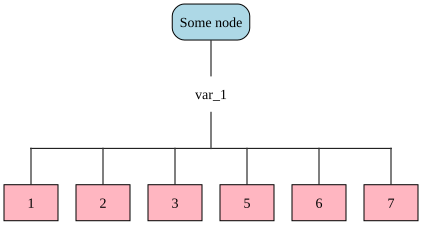

In [4]:
from graphviz import Digraph

dot = Digraph("tree")
dot.attr(rankdir="TB")

dot.node("Node_1", "Some node", shape="box", style="rounded,filled", fillcolor="lightblue")

dot.edge("Node_1", "var_1", arrowhead="none")
dot.node("var_1", "var_1", shape="plaintext")

n_subnodes=6


def create_subnode(i):
        dot.edge(f"anchor_{i}", f"{i}", weight="10", arrowhead="none")
        dot.node(f"{i}", f"{i}", shape="box", style="filled", fillcolor="lightpink")

def set_as_same_height(nodes):
    with dot.subgraph() as s:
        s.attr(rank="same")
        for node in nodes:
            s.node(node)

n_anchors = (n_subnodes // 2) * 2 + 1
mid_anchor = n_anchors // 2 + 1
rg = range(1, n_anchors + 1)


set_as_same_height([f"anchor_{i}" for i in rg])

# link the anchors together and to the variable
for i in rg:
    # create all anchors
    dot.node(f"anchor_{i}", "", shape="point", width="0.00")

    # nodes and anchors to the left of the middle anchor
    if i < mid_anchor:
        dot.edge(f"anchor_{i}", f"anchor_{i+1}", arrowhead="none")

        create_subnode(i)

    if i == mid_anchor:
        dot.edge("var_1", f"anchor_{i}", arrowhead="none")

        if n_subnodes % 2 != 0:
            create_subnode(i)

    # nodes and anchors to the right of the middle anchor
    if i > mid_anchor:
        dot.edge(f"anchor_{i-1}", f"anchor_{i}", arrowhead="none")

        create_subnode(i)


dot

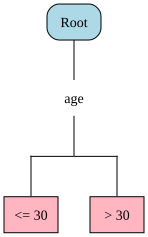

In [2]:
from controltree.rendering import TreeRenderer

tree = TreeRenderer()
root_id = tree.node(label="Root", color="lightblue")
var_id, child_ids = tree.add_split(
    to=root_id,
    name="age",
    labels=["<= 30", "> 30"],
)
tree.draw()

In [3]:
# Step 1) Load data and start session
df = load_titanic()

tree = start_manual_tree(df, base_color="#1f77b4")
tree.set_target("survived", exclude_cols=["alive"], min_samples_leaf=20)

print(f"Rows: {len(df)}")
print("Session ready. Root node id is 'root'.")


Rows: 891
Session ready. Root node id is 'root'.


Suggested variables (ranked by best gain):
 1. feature=who | best_gain=0.14679 | best_cutpoint=man | candidates=3
 2. feature=adult_male | best_gain=0.14679 | best_cutpoint=True | candidates=2
 3. feature=sex | best_gain=0.13965 | best_cutpoint=male | candidates=2
 4. feature=pclass | best_gain=0.04914 | best_cutpoint=2.0 | candidates=2
 5. feature=class | best_gain=0.04914 | best_cutpoint=Third | candidates=3
Best split candidates:
 1. feature=who | cutpoint=man | rule: who == man  (gain=0.14679, left=537, right=354)
 2. feature=who | cutpoint=woman | rule: who == woman  (gain=0.12138, left=271, right=620)
 3. feature=who | cutpoint=child | rule: who == child  (gain=0.00876, left=83, right=808)
Created child nodes: ['1', '2']


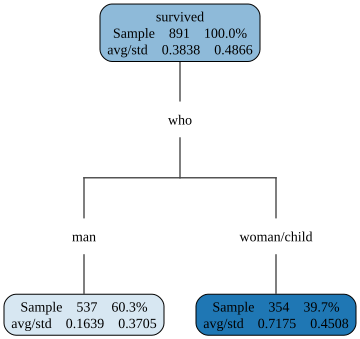

In [4]:
# Step 2) Suggest best variables for this node`n
node_id = "root"
variable_suggestions = tree.suggest_variables(node_id=node_id, top_n=5)
tree.print_variable_suggestions(variable_suggestions)
cutpoint_suggestions = tree.suggest_cutpoints(node_id=node_id, feature='who', top_n=10)
tree.print_suggestions(cutpoint_suggestions)
children = tree.confirm_manual_split(node_id=node_id, feature='who', categories=['man'], other_label="woman/child", other_position=2)
print("Created child nodes:", children)

tree.draw_tree()

Suggested variables (ranked by best gain):
 1. feature=fare | best_gain=0.02083 | best_cutpoint=26.0 | candidates=19
 2. feature=pclass | best_gain=0.02035 | best_cutpoint=1.0 | candidates=2
 3. feature=class | best_gain=0.02035 | best_cutpoint=First | candidates=3
Best split candidates:
 1. feature=class | cutpoint=First | rule: class == First  (gain=0.02035, left=119, right=418)
 2. feature=class | cutpoint=Third | rule: class == Third  (gain=0.00586, left=319, right=218)
 3. feature=class | cutpoint=Second | rule: class == Second  (gain=0.00312, left=99, right=438)
Created child nodes: ['1_1', '1_2']


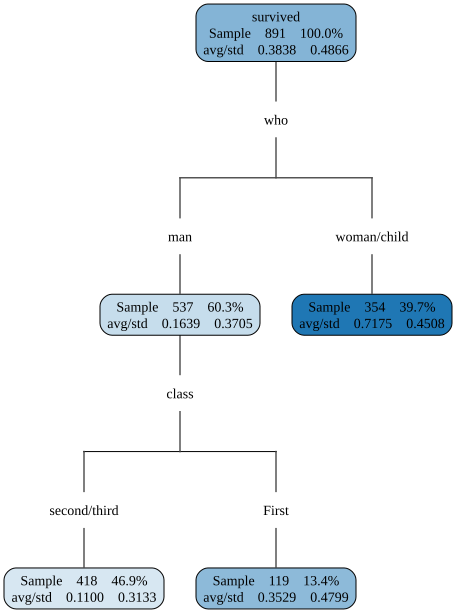

In [5]:
node_id = "1"
variable_suggestions = tree.suggest_variables(node_id=node_id, top_n=3)
tree.print_variable_suggestions(variable_suggestions)

cutpoint_suggestions = tree.suggest_cutpoints(node_id=node_id, feature='class', top_n=10)
tree.print_suggestions(cutpoint_suggestions)
children = tree.confirm_manual_split(node_id=node_id, feature='class', categories=['First'], other_label="second/third", other_position=1)
print("Created child nodes:", children)

tree.show_tree()

Suggested variables (ranked by best gain):
 1. feature=fare | best_gain=0.00173 | best_cutpoint=34.731249999999946 | candidates=18
 2. feature=age | best_gain=0.00159 | best_cutpoint=32.02894736842104 | candidates=19
 3. feature=embarked | best_gain=0.00156 | best_cutpoint=C | candidates=3
Best split candidates:
 1. feature=class | cutpoint=Third | rule: class == Third  (gain=0.00053, left=319, right=99)
 2. feature=class | cutpoint=Second | rule: class == Second  (gain=0.00053, left=99, right=319)
Created child nodes: ['1_1_1', '1_1_2']


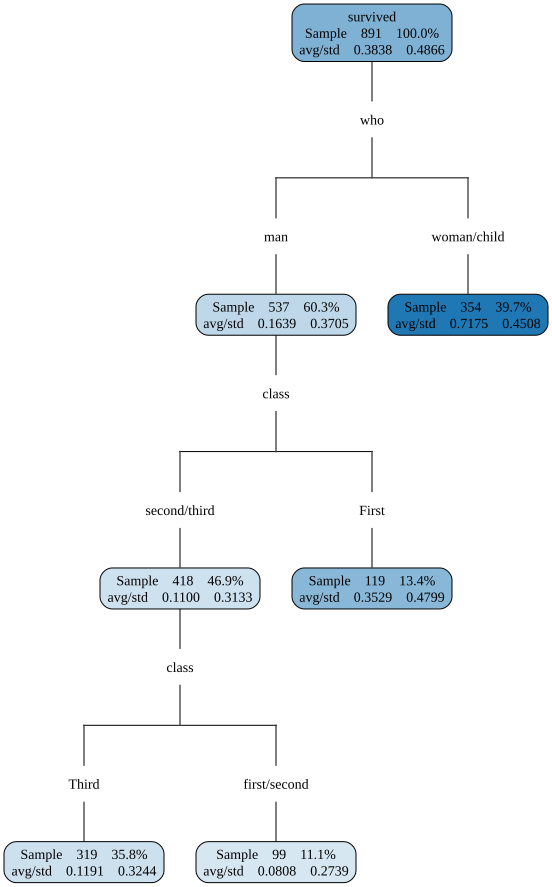

In [6]:
node_id = "1_1"
variable_suggestions = tree.suggest_variables(node_id=node_id, top_n=3)
tree.print_variable_suggestions(variable_suggestions)

cutpoint_suggestions = tree.suggest_cutpoints(node_id=node_id, feature='class', top_n=10)
tree.print_suggestions(cutpoint_suggestions)

children = tree.confirm_manual_split(node_id=node_id, feature='class', categories=['Third'], other_label="first/second", other_position=2)
print("Created child nodes:", children)

tree.show_tree()

Suggested variables (ranked by best gain):
 1. feature=fare | best_gain=0.00173 | best_cutpoint=34.731249999999946 | candidates=18
 2. feature=age | best_gain=0.00159 | best_cutpoint=32.02894736842104 | candidates=19
 3. feature=embarked | best_gain=0.00156 | best_cutpoint=C | candidates=3
 4. feature=embark_town | best_gain=0.00156 | best_cutpoint=Cherbourg | candidates=3
 5. feature=pclass | best_gain=0.00053 | best_cutpoint=2.0 | candidates=1
 6. feature=class | best_gain=0.00053 | best_cutpoint=Third | candidates=2
 7. feature=alone | best_gain=0.00033 | best_cutpoint=True | candidates=2
 8. feature=sibsp | best_gain=0.00019 | best_cutpoint=0.0 | candidates=1
 9. feature=parch | best_gain=0.00011 | best_cutpoint=0.0 | candidates=1
Best split candidates:
 1. feature=age | cutpoint=32.0 | rule: age <= 32.0  (gain=0.00159, left=210, right=208)
 2. feature=age | cutpoint=32.79827586206896 | rule: age <= 32.79827586206896  (gain=0.00153, left=211, right=207)
 3. feature=age | cutpoint=3

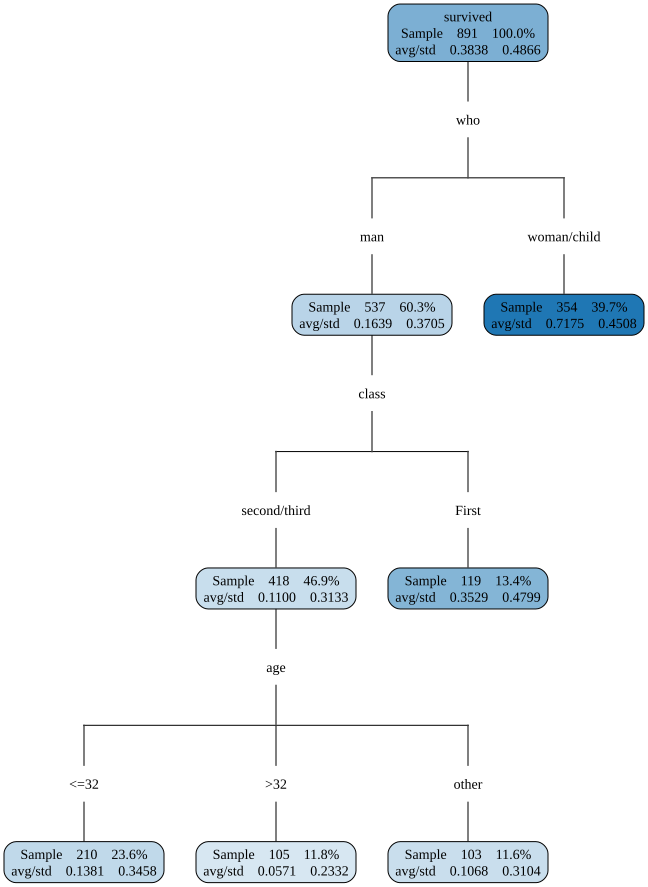

In [7]:
node_id = "1_1"
variable_suggestions = tree.suggest_variables(node_id=node_id, top_n=10)
tree.print_variable_suggestions(variable_suggestions)

cutpoint_suggestions = tree.suggest_cutpoints(node_id=node_id, feature='age', top_n=10)
tree.print_suggestions(cutpoint_suggestions)

# children = tree.confirm_manual_split(node_id=node_id, feature='embarked', categories=['C', 'S', 'Q'])
# children = tree.confirm_manual_split(node_id=node_id, feature='alone', categories=[False, True], force_categorical=True)
children = tree.confirm_manual_split(node_id=node_id, feature='age', categories=[32])
print("Created child nodes:", children)

tree.show_tree()

In [ ]:
# Step 6) Save final version only when you are happy
output_dir = ROOT / "tests" / "_artifacts"
output_dir.mkdir(parents=True, exist_ok=True)
png_path = output_dir / "decision_tree_2.png"
tree.draw_tree(png_path)
png_path